## Setup

In [1]:
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.ndimage import rotate
from torch import nn
from torch.nn import functional as func
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from edl_losses import EDLLoss, FEDLLoss, GENLoss, edl_inference, fedl_inference

# Constants
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 30

# Data preparation
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256)

100.0%
100.0%
100.0%
100.0%


### Digit Rotation Plots

We want to plot the uncertainty/accuracy for possible rotation of the digit `1`.

In [2]:
def find_digit(dataset: torch.utils.data.Dataset, digit: int = 1) -> torch.Tensor:
    """Return the first occurrence of `digit` from the dataset as a (1,1,28,28) tensor.

    Arguments:
        dataset (torch.utils.data.Dataset): The dataset to search through.
        digit (int): The digit to find (0-9).

    Returns:
        torch.Tensor: A tensor of shape (1, 1, 28, 28) containing the first occurrence of the specified digit.

    """
    for img, label in dataset:
        if label == digit:
            return img.unsqueeze(0)  # (1, 1, 28, 28)

    msg = f"Digit {digit} not found in dataset."
    raise ValueError(msg)


def rotate_image(img_tensor: torch.Tensor, angle: float) -> torch.Tensor:
    """Rotate a (1, 1, 28, 28) tensor by `angle` degrees.

    Arguments:
        img_tensor (torch.Tensor): A tensor of shape (1, 1, 28, 28) representing the image to rotate.
        angle (float): The angle in degrees to rotate the image. Positive values rotate counter-clockwise.

    Returns:
        torch.Tensor: A tensor of shape (1, 1, 28, 28) containing the rotated image.

    """
    img_np = img_tensor.squeeze().numpy()  # (28, 28)
    rotated = rotate(img_np, angle, reshape=False)  # same shape, fills with 0

    return torch.tensor(rotated, dtype=torch.float32).unsqueeze(0).unsqueeze(0)


digit_img = find_digit(train_data, digit=1)
n_steps = 37  # ~5° increments like the paper
angles = np.linspace(0, 180, n_steps)


def plot_rotation_analysis(
    model: nn.Module,
    inference_fn: Callable,
    true_class: int = 1,
) -> None:
    """Plot the rotation analysis results.

    Arguments:
        model (nn.Module): The trained model to analyze.
        inference_fn (Callable): The inference function to use (e.g., edl_inference).
        true_class (int): The true class index to plot the probability for (default is 1 for digit '1').

    """
    all_probs = np.zeros((n_steps, 10))
    all_uncertainty = np.zeros(n_steps)

    for i, angle in enumerate(angles):
        rotated = rotate_image(digit_img, angle)
        model_results = model(rotated.to(DEVICE))
        if not isinstance(model_results, tuple):
            model_results = (model_results,)
        _, uncertainty, class_probs = inference_fn(*model_results)
        all_probs[i] = class_probs.detach().squeeze().cpu().numpy()
        all_uncertainty[i] = uncertainty.detach().cpu().item()

    p_correct = all_probs[:, true_class]

    plt.figure(figsize=(8, 5))

    plt.plot(angles, p_correct, label="P(correct)", color="black", marker="s", markevery=4, linewidth=1.5)
    plt.plot(
        angles,
        all_uncertainty,
        label="uncertainty",
        color="green",
        marker="x",
        markevery=4,
        linewidth=1.5,
        linestyle="--",
    )

    plt.title("Rotation Analysis of Digit '1'")
    plt.xlabel("Rotation Angle")
    plt.ylabel("Probability / Uncertainty")
    plt.xlim(0, 180)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Evaluation function

In [3]:
def evaluate_model(model: nn.Module, inference_fn: Callable) -> None:
    """Evaluate the model on the test set and print accuracy and uncertainty statistics.

    Arguments:
        model (nn.Module): The trained model to evaluate.
        inference_fn (Callable): The inference function to use (e.g., edl_inference).

    """
    model.eval()

    correct = total = 0
    mean_uncertainty_correct = mean_uncertainty_wrong = 0
    n_correct = n_wrong = 0

    with torch.no_grad():
        for x, y in test_loader:
            model_results = model(x.to(DEVICE))
            if not isinstance(model_results, tuple):
                model_results = (model_results,)
            pred, uncertainty, _ = inference_fn(*model_results)

            mask_correct = pred == y.to(DEVICE)
            mask_wrong = ~mask_correct

            correct += mask_correct.sum().item()
            total += y.to(DEVICE).size(0)
            mean_uncertainty_correct += uncertainty[mask_correct].sum().item()
            mean_uncertainty_wrong += uncertainty[mask_wrong].sum().item()
            n_correct += mask_correct.sum().item()
            n_wrong += mask_wrong.sum().item()

    print(f"\nTest accuracy: {correct / total:.4f}")
    print(f"Mean uncertainty — correct: {mean_uncertainty_correct / max(n_correct, 1):.4f}")
    print(f"Mean uncertainty — wrong: {mean_uncertainty_wrong / max(n_wrong, 1):.4f}")

### LeNet Model

We will evaluate all EDL loss functions using the same LeNet architecture

In [4]:
class LeNet(nn.Module):
    """Standard LeNet-5 for MNIST. Returns flat features before classifier."""

    def __init__(self) -> None:
        """Initialize the LeNet architecture."""
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 20, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(20, 50, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(nn.Linear(800, 500), nn.ReLU())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the LeNet architecture.

        Arguments:
            x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

        Returns:
            Tensor of shape (batch_size, 500) representing the features before the classifier.

        """
        return self.fc(self.features(x).flatten(1))

## EDL

In [5]:
class EDLModel(nn.Module):
    """EDL classifier with LeNet backbone. Outputs raw logits for evidence (no softmax)."""

    def __init__(self, num_classes: int = 10) -> None:
        """Initialize the EDL model architecture."""
        super().__init__()
        self.backbone = LeNet()
        self.classifier = nn.Linear(500, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the EDL model.

        Arguments:
            x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

        Returns:
            Tensor of shape (batch_size, num_classes) representing raw logits for evidence.

        """
        return self.classifier(self.backbone(x))  # raw logits, NO softmax

In [6]:
model = EDLModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        loss = EDLLoss()(model(x.to(DEVICE)), y.to(DEVICE), epoch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch}/{NUM_EPOCHS} loss={total_loss / len(train_loader):.4f}")

Epoch 1/30 loss=0.3655
Epoch 2/30 loss=0.2153
Epoch 3/30 loss=0.1980
Epoch 4/30 loss=0.1863
Epoch 5/30 loss=0.1819
Epoch 6/30 loss=0.1750
Epoch 7/30 loss=0.1739
Epoch 8/30 loss=0.1731
Epoch 9/30 loss=0.1729
Epoch 10/30 loss=0.1680
Epoch 11/30 loss=0.1638
Epoch 12/30 loss=0.1553
Epoch 13/30 loss=0.1534
Epoch 14/30 loss=0.1506
Epoch 15/30 loss=0.1504
Epoch 16/30 loss=0.1456
Epoch 17/30 loss=0.1463


KeyboardInterrupt: 


Test accuracy: 0.6942
Mean uncertainty — correct: 0.0678
Mean uncertainty — wrong: 0.9951


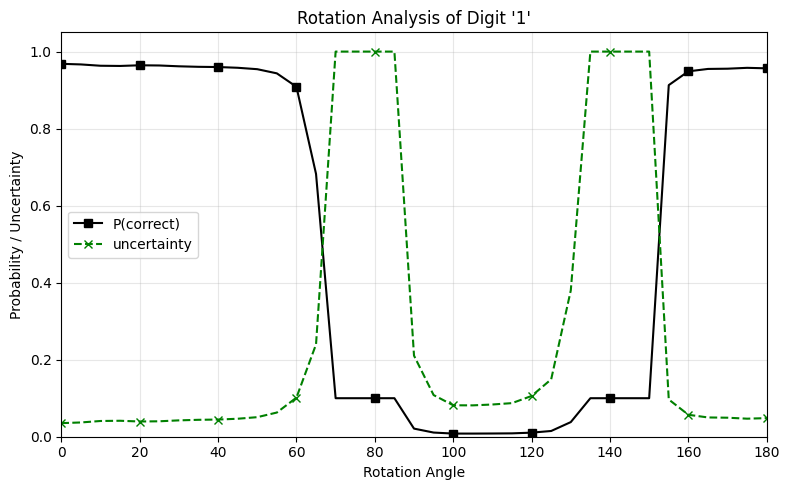

In [ ]:
evaluate_model(model, edl_inference)
plot_rotation_analysis(model, edl_inference)

## GEN

In [ ]:
class GENModel(nn.Module):
    """Same classifier as EDL. OOD samples are generated externally during training."""

    def __init__(self, num_classes: int = 10) -> None:
        """Initialize the GEN model architecture."""
        super().__init__()
        self.backbone = LeNet()
        self.classifier = nn.Linear(500, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the GEN model.

        Arguments:
            x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

        Returns:
            Tensor of shape (batch_size, num_classes) representing raw logits for classification.

        """
        return self.classifier(self.backbone(x))

In [ ]:
def _make_ood_samples(x: torch.Tensor) -> torch.Tensor:
    """Add Gaussian noise to push samples off-distribution.

    In production this would be the VAE+GAN generator from the paper.

    Arguments:
        x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

    Returns:
        Tensor of the same shape as x, but with added noise to simulate OOD samples.

    """
    return torch.clamp(x + 0.3 * torch.randn_like(x), 0, 1)


model = GENModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x_ood = _make_ood_samples(x.to(DEVICE))
        optimizer.zero_grad()
        loss = GENLoss()(model(x.to(DEVICE)), model(x_ood), y.to(DEVICE))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}/{NUM_EPOCHS} loss={total_loss / len(train_loader):.4f}")

Epoch 1/30 loss=0.4769
Epoch 2/30 loss=0.1224
Epoch 3/30 loss=0.0871
Epoch 4/30 loss=0.0683
Epoch 5/30 loss=0.0523
Epoch 6/30 loss=0.0440
Epoch 7/30 loss=0.0381
Epoch 8/30 loss=0.0319
Epoch 9/30 loss=0.0225
Epoch 10/30 loss=0.0228
Epoch 11/30 loss=0.0172
Epoch 12/30 loss=0.0158
Epoch 13/30 loss=0.0174
Epoch 14/30 loss=0.0146
Epoch 15/30 loss=0.0127
Epoch 16/30 loss=0.0090
Epoch 17/30 loss=0.0057
Epoch 18/30 loss=0.0117
Epoch 19/30 loss=0.0094
Epoch 20/30 loss=0.0133
Epoch 21/30 loss=0.0087
Epoch 22/30 loss=0.0059
Epoch 23/30 loss=0.0042
Epoch 24/30 loss=0.0019
Epoch 25/30 loss=0.0070
Epoch 26/30 loss=0.0090
Epoch 27/30 loss=0.0065
Epoch 28/30 loss=0.0087
Epoch 29/30 loss=0.0088
Epoch 30/30 loss=0.0014



Test accuracy: 0.9936
Mean uncertainty — correct: 0.4044
Mean uncertainty — wrong: 0.7884


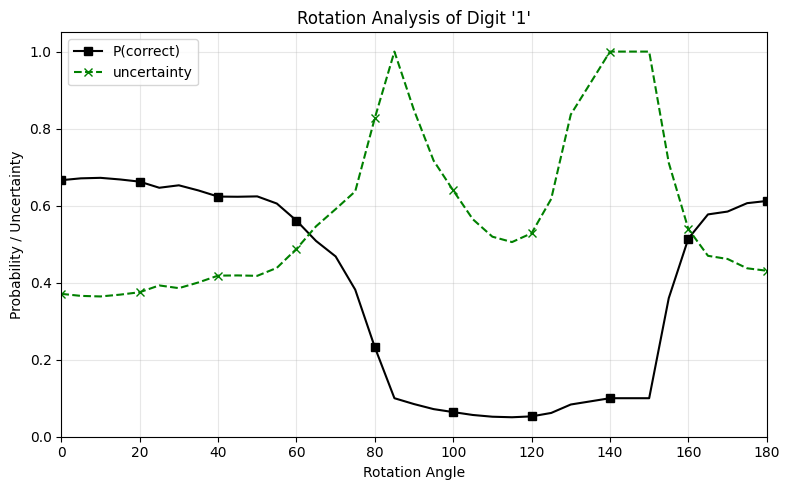

In [ ]:
evaluate_model(model, edl_inference)
plot_rotation_analysis(model, edl_inference)

## F-EDL

In [ ]:
class FEDLModel(nn.Module):
    """F-EDL classifier with LeNet backbone. Outputs separate heads for alpha, p, and tau."""

    def __init__(self, num_classes: int = 10, mlp_hidden: int = 64) -> None:
        """Initialize the F-EDL model architecture."""
        super().__init__()
        self.backbone = LeNet()

        # Three separate heads
        self.head_alpha = nn.Linear(500, num_classes)  # evidence
        self.head_p = nn.Linear(500, num_classes)  # allocation probs
        self.head_tau = nn.Sequential(  # dispersion
            nn.Linear(500, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, 1),
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Forward pass through the F-EDL model.

        Arguments:
            x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

        Returns:
            alpha: Tensor of shape (batch_size, num_classes) representing evidence for each class.
            p: Tensor of shape (batch_size, num_classes) representing allocation probabilities.
            tau: Tensor of shape (batch_size,) representing dispersion.

        """
        z = self.backbone(x)
        alpha = torch.exp(self.head_alpha(z))
        p = torch.softmax(self.head_p(z), dim=-1)
        tau = func.softplus(self.head_tau(z)).squeeze(-1)
        return alpha, p, tau

In [ ]:
model = FEDLModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        alpha, p, tau = model(x.to(DEVICE))
        alpha = torch.clamp(alpha, 1e-6, 1e4)
        tau = torch.clamp(tau, 1e-6, 1e4)
        loss = FEDLLoss()(alpha, p, tau, y.to(DEVICE))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}/{NUM_EPOCHS} loss={total_loss / len(train_loader):.4f}")

Epoch 1/30 loss=0.2937
Epoch 2/30 loss=0.0661
Epoch 3/30 loss=0.0461
Epoch 4/30 loss=0.0355
Epoch 5/30 loss=0.0290
Epoch 6/30 loss=0.0231
Epoch 7/30 loss=0.0201
Epoch 8/30 loss=0.0174
Epoch 9/30 loss=0.0151
Epoch 10/30 loss=0.0123
Epoch 11/30 loss=0.0109
Epoch 12/30 loss=0.0112
Epoch 13/30 loss=0.0105
Epoch 14/30 loss=0.0084
Epoch 15/30 loss=0.0073
Epoch 16/30 loss=0.0072
Epoch 17/30 loss=0.0076
Epoch 18/30 loss=0.0067
Epoch 19/30 loss=0.0080
Epoch 20/30 loss=0.0067
Epoch 21/30 loss=0.0051
Epoch 22/30 loss=0.0060
Epoch 23/30 loss=0.0063
Epoch 24/30 loss=0.0066
Epoch 25/30 loss=0.0063
Epoch 26/30 loss=0.0053
Epoch 27/30 loss=0.0049
Epoch 28/30 loss=0.0051
Epoch 29/30 loss=0.0051
Epoch 30/30 loss=0.0047



Test accuracy: 0.9933
Mean uncertainty — correct: 0.0029
Mean uncertainty — wrong: 0.2288


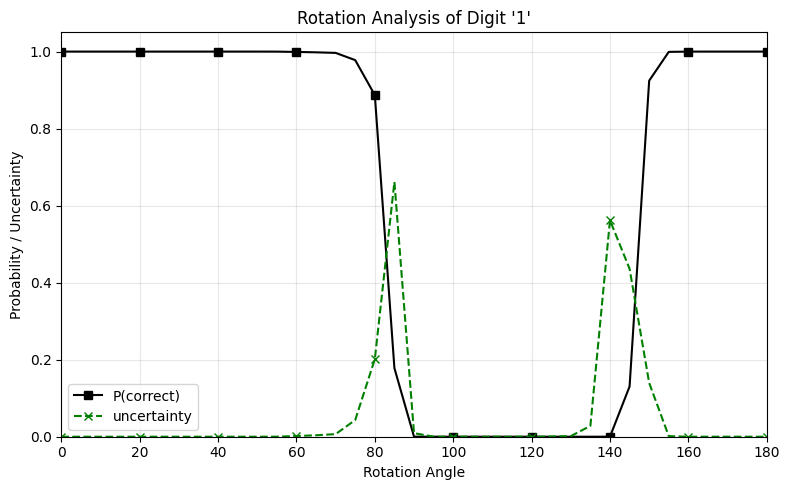

In [ ]:
evaluate_model(model, fedl_inference)
plot_rotation_analysis(model, fedl_inference)